# Model discrepancy with a Gaussian process

Every physics model we calibrate is wrong somewhere. Often it's wrong in a *structured* way: it drifts away from reality smoothly as a function of $x$, rather than missing randomly point by point. When that happens, the residuals it leaves behind are correlated with each other. If our covariance assumes the points are independent, the likelihood reads those correlated residuals as a series of independent confirmations, and the posterior ends up far more confident than it has any right to be.

The standard way to handle this is from [Kennedy & O'Hagan (2001)](https://doi.org/10.1111/1467-9868.00294), who add a *discrepancy* term $\delta(x)$ to the model, so that reality is $y_m(x;\theta) + \delta(x)$. Usually $\delta$ gets a [Gaussian process](https://en.wikipedia.org/wiki/Gaussian_process) prior. People mean two rather different things when they say this, and it's worth separating them before we start:

- A **mean-zero discrepancy** only learns the *covariance* of the mismatch. We tell the likelihood that the truth departs smoothly from our model, roughly how far and how smoothly, and then integrate over every departure consistent with that. We never try to say what $\delta(x)$ actually *is*.
- A **non-zero-mean discrepancy** goes further. It gives the mismatch parameters of its own and builds a posterior for the discrepancy function itself (recipes 8 and 36).

In this notebook we'll only do the first. We'll also let the size of the discrepancy **grow with $x$**. That's genuine prior knowledge in this problem: the data look like a straight line at small $x$ and stop looking like one further out, so we trust our model more on the left than on the right.

Recipes: 7

In [1]:
import corner
import dynesty
import emcee
import jitr
import matplotlib.pyplot as plt
import numpy as np
import plotstyle
from jitr.optical_potentials.potential_forms import (
    thomas_safe,
    woods_saxon_prime_safe,
    woods_saxon_safe,
)
from scipy import stats
from sklearn.gaussian_process.kernels import Matern, WhiteKernel

import rxmc as rx
from rxmc import terms as T
from rxmc import transforms as tf

plotstyle.use()

## A line, and a truth that leaves it

We'll make synthetic data from a truth that is a straight line plus a small quadratic departure, $0.03\,x^2$. At the left edge of the data that departure is 0.001, far below the measurement noise of 0.02, so we couldn't see it even if we tried. By $x = 5$ it has grown to 0.75, thirty-seven times the size of an error bar. A straight-line model is therefore an excellent description at small $x$ and a hopeless one at large $x$, which is exactly the situation a growing discrepancy amplitude is meant to describe.

In [2]:
M_TRUE, B_TRUE = 0.8, 1.0


def defect(x):
    return 0.03 * np.asarray(x, dtype=float) ** 2


def truth(x):
    return M_TRUE * np.asarray(x, dtype=float) + B_TRUE + defect(x)


rng = np.random.default_rng(7)
x = np.linspace(0.2, 5.0, 30)
noise = 0.02
data = rx.Dataset(
    x, truth(x) + rng.normal(0.0, noise, x.size), np.full(x.size, noise), label="toy"
)
x_fine = np.linspace(0.0, 6.0, 80)

In [3]:
print(
    "defect / noise at x = 0.2, 2.5, 5.0:", np.round(defect([0.2, 2.5, 5.0]) / noise, 1)
)

defect / noise at x = 0.2, 2.5, 5.0: [ 0.1  9.4 37.5]


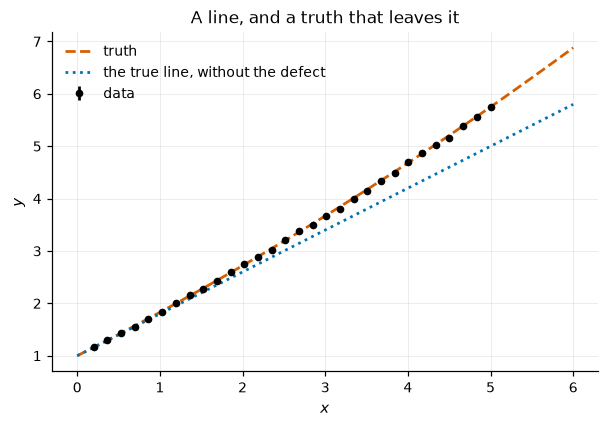

In [4]:
fig, ax = plt.subplots()
ax.errorbar(data.x, data.y, data.y_err, fmt="o", ms=4, color="k", label="data")
ax.plot(x_fine, truth(x_fine), "--", color=plotstyle.COLOURS[1], label="truth")
ax.plot(
    x_fine,
    M_TRUE * x_fine + B_TRUE,
    ":",
    color=plotstyle.COLOURS[0],
    label="the true line, without the defect",
)
ax.set(xlabel="$x$", ylabel="$y$", title="A line, and a truth that leaves it")
ax.legend()
plt.show()

## Four ways to say "the model is wrong"

We'll fit the same line four times, and the only thing we'll change between fits is the covariance:

1. **Statistics only.** We use the reported errors and nothing else, which amounts to claiming the line is perfect.
2. **An uncorrelated proportional error** (`T.proportional_error`). Every point gets some extra slack, in proportion to its size, but each point's slack is *independent* of its neighbours'.
3. **A GP with a constant amplitude.** Now the discrepancy is smooth and mean-zero, but it's allowed to be the same size everywhere.
4. **A GP whose amplitude grows with $x$** (`T.exp_growth_amplitude`). This is the same smooth discrepancy, except that it can be small where we trust the line and large where we don't.

Only the last one encodes what we actually believe about this problem. The nice thing is that each of these is a single `Term` in a `Constraint`, so the inference code doesn't change between them at all. The kernel is a [Matérn](https://en.wikipedia.org/wiki/Mat%C3%A9rn_covariance_function) with $\nu = 5/2$: smooth, but not as unrealistically smooth as a squared exponential.

In [5]:
m = rx.Parameter("m", prior=stats.norm(0.0, 2.0), latex="m")
b = rx.Parameter("b", prior=stats.norm(0.0, 2.0), latex="b")
line = rx.Model(lambda x, m, b: m * x + b, [m, b])
comp = rx.Comparison(data, line)

gamma = rx.Parameter(
    "log_gamma", prior=stats.norm(np.log(0.05), 1.0), latex=r"\log\gamma"
)
log_A = rx.Parameter("log_A", prior=stats.norm(np.log(0.02), 1.5), latex=r"\log A")
amp_slope = rx.Parameter("amp_slope", prior=stats.norm(1.0, 1.0), latex=r"s_A")
log_ell = rx.Parameter("log_ell", prior=stats.norm(0.5, 1.0), latex=r"\log \ell")

kernel = Matern(length_scale=2.0, nu=2.5) + WhiteKernel(1e-6, "fixed")
gp_const = T.kernel(
    kernel, params=[log_ell], amplitude=T.constant_amplitude, amplitude_params=(log_A,)
)
gp_grow = T.kernel(
    kernel,
    params=[log_ell],
    amplitude=T.exp_growth_amplitude(5.0),
    amplitude_params=(log_A, amp_slope),
)

In [6]:
problems = {
    "statistics only": rx.Problem([rx.Constraint([comp])]),
    "proportional error": rx.Problem(
        [rx.Constraint([comp], terms=[T.proportional_error(gamma, averaging=True)])]
    ),
    "GP, constant amplitude": rx.Problem([rx.Constraint([comp], terms=[gp_const])]),
    "GP, growing amplitude": rx.Problem([rx.Constraint([comp], terms=[gp_grow])]),
}
for name, p in problems.items():
    print(f"{name:24s} {p.names}")

statistics only          ['m', 'b']
proportional error       ['m', 'b', 'log_gamma']
GP, constant amplitude   ['m', 'b', 'log_ell', 'log_A']
GP, growing amplitude    ['m', 'b', 'log_ell', 'log_A', 'amp_slope']


In [7]:
def fit(problem, seed, n_walkers=24, n_steps=3000):
    sampler = emcee.EnsembleSampler(n_walkers, problem.ndim, problem.log_posterior)
    sampler.random_state = np.random.RandomState(seed).get_state()
    sampler.run_mcmc(problem.sample_prior(n_walkers, rng=seed), n_steps, progress=False)
    return sampler.get_chain(discard=n_steps // 3, thin=5, flat=True)


samples = {name: fit(p, seed=i) for i, (name, p) in enumerate(problems.items())}

In [8]:
for name, p in problems.items():
    s = samples[name]
    cm, cb = p.columns(m)[0], p.columns(b)[0]
    pull_m = (s[:, cm].mean() - M_TRUE) / s[:, cm].std()
    pull_b = (s[:, cb].mean() - B_TRUE) / s[:, cb].std()
    print(
        f"{name:24s} m = {s[:, cm].mean():.3f} +/- {s[:, cm].std():.3f} "
        f"(pull {pull_m:+5.1f})   b = {s[:, cb].mean():.3f} +/- {s[:, cb].std():.3f} "
        f"(pull {pull_b:+5.1f})"
    )

statistics only          m = 0.953 +/- 0.003 (pull +60.2)   b = 0.858 +/- 0.007 (pull -19.0)
proportional error       m = 0.775 +/- 1.043 (pull  -0.0)   b = 0.154 +/- 2.262 (pull  -0.4)
GP, constant amplitude   m = 0.959 +/- 0.062 (pull  +2.6)   b = 1.046 +/- 0.366 (pull  +0.1)
GP, growing amplitude    m = 0.830 +/- 0.071 (pull  +0.4)   b = 0.941 +/- 0.165 (pull  -0.4)


### What those four rows tell us

**Statistics only** is the cautionary tale. It gives $m = 0.953 \pm 0.003$, sixty standard deviations away from the truth. The line has no way to say "I'm wrong at large $x$", so it tilts to chase the defect and then reports a precision of three parts in a thousand. This is worth remembering: an unmodelled discrepancy doesn't make our answer vaguer, it *moves* it, and confidently.

**The proportional error** does cover the truth, but look at how it manages it: $m = 0.775 \pm 1.043$. Independent slack at each point can only inflate the errors, and to cover a coherent, smooth departure it has to inflate them until the slope means nothing at all.

**The constant-amplitude GP** knows the defect is smooth, and that alone helps a great deal: $m = 0.959 \pm 0.062$, compared with sixty sigma before. It's still 2.6 sigma out, though. The trouble is that one amplitude has to serve both ends of the range. It has to be large enough to cover $x = 5$, which makes it far too generous at $x = 0.2$, and so it lets the fit off the hook exactly where the data are most informative about the line.

**The growing amplitude**, the one that matches what we believe, lands on the truth: $m = 0.830 \pm 0.071$ and $b = 0.941 \pm 0.165$, both within half a sigma. The fit also tells us it really did need the growth, since the inferred slope of the amplitude comes out around $+1.8$ rather than zero.

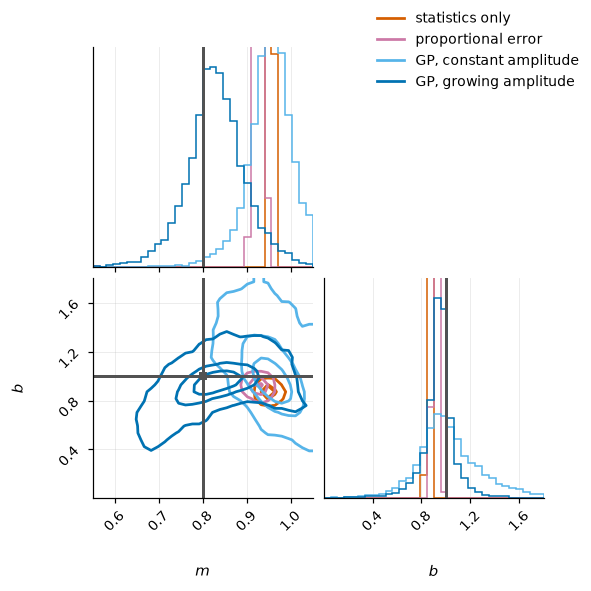

In [9]:
fig = None
colours = [plotstyle.COLOURS[i] for i in (1, 3, 5, 0)]
for (name, p), colour in zip(problems.items(), colours):
    fig = corner.corner(
        samples[name][:, p.columns(line.params)],
        fig=fig,
        labels=["$m$", "$b$"],
        truths=[M_TRUE, B_TRUE],
        range=[(0.55, 1.05), (0.0, 1.8)],
        **plotstyle.corner_kwargs(
            color=colour, fill_contours=False, plot_density=False, show_titles=False
        ),
    )
fig.legend(
    handles=[plt.Line2D([], [], color=c, label=n) for n, c in zip(problems, colours)],
    loc="upper right",
    fontsize=9,
)
plt.show()

## Propagating the whole uncertainty

The line's own posterior band can't bend. It has two parameters, so all it can ever produce is a fan of straight lines. The GP supplies the piece that *can* bend. But once we have a discrepancy in the mix, there are actually three different things we might draw, and they answer different questions, so let's go through them carefully.

Because our kernel declares a **mean-zero** discrepancy, the likelihood we fit was already the marginal over $\delta$, a [multivariate normal](https://en.wikipedia.org/wiki/Multivariate_normal_distribution) whose covariance is the sum of the experimental covariance and the kernel:

$$\mathbf{y} \sim \mathcal{N}\big(y_m(\mathbf{x};\theta),\ \Sigma(\theta)\big),
\qquad \Sigma(\theta) = \Sigma_\mathrm{exp} + K(\theta).$$

In other words, the fit integrated the discrepancy out rather than estimating it. The first predictive that matches this is a correlated draw from the inferred kernel, centred on the model's *own* prediction, with one draw for every posterior sample:

$$y_* = y_m(x_*;\theta) + \delta, \qquad
\delta \sim \mathcal{N}\big(0,\ K_{**}(\theta)\big).$$

We get this from `rx.predictive.grid_draws` by naming just the kernel in `terms=`. It's a statement about **the model**: where it may be wrong, and by how much. Notice that it carries no experimental error, so it isn't what we should compare our data against. For that we need the second object, which includes every term:

$$y = y_m(x;\theta) + \delta + \varepsilon, \qquad
\varepsilon \sim \mathcal{N}\big(0,\ \Sigma_\mathrm{exp}\big).$$

`terms=` is how we choose between them. Below we'll draw the first on the fine grid, naming only the kernel. We have to, because the reported errors are one number per *measured* point, and they simply don't exist at a new $x$. Then we'll draw the second at the measured points, where they do exist.

The third object, which we're deliberately not going to use, conditions the discrepancy on the observed residuals $r$:

$$\delta \mid r \sim \mathcal{N}\big(K_{*t}(K_{tt}+N)^{-1}r,\;
K_{**} - K_{*t}(K_{tt}+N)^{-1}K_{t*}\big).$$

This is ordinary GP regression, as in [Rasmussen & Williams (2006), ch. 2](http://gaussianprocess.org/gpml/), and it's available as `rx.predictive.gp_predictive_draws(..., conditioned=True)`. What it does is interpolate the residuals, stacking a data-driven regression on top of the model. Where that band is narrow, it's narrow because the data pinned it there, not because the model is any good. Our question in this notebook is where the *model* fails, so we want the first two objects.

One more detail matters for what follows. Each draw is a whole curve, not a column of independent points. For every posterior sample, `grid_draws` re-evaluates the kernel, growing amplitude included, on the new grid, takes its [Cholesky factor](https://en.wikipedia.org/wiki/Cholesky_decomposition) once, and draws a single correlated vector from it. That's what lets us ask a question like "how far does the truth wander from the model *anywhere* in this range?" and get a sensible answer.

In [10]:
def mean_band(problem, samples_, levels=(16, 84)):
    # the fan of model curves alone, with no error model at all
    return rx.predictive.grid_draws(
        problem,
        line.bind(x_fine),
        x_fine,
        samples_[::10],
        model_only=True,
        levels=levels,
    )


p_grow = problems["GP, growing amplitude"]
s_grow = samples["GP, growing amplitude"]

# the model plus its discrepancy, on any grid we like: name the kernel alone
band_gp = rx.predictive.grid_draws(
    p_grow,
    line.bind(x_fine),
    x_fine,
    s_grow[::10],
    terms=[gp_grow],
    levels=(16, 84),
    rng=4,
)
# every term the error model declares, at the points that were measured
draws_data = rx.diagnostics.predictive_draws(
    p_grow, s_grow[::10], n_rep=2, rng=4, return_draws=True
)

In [11]:
w = band_gp[1] - band_gp[0]
print(
    "68 % width of model + discrepancy at x = 0.2, 2.5, 5.0:",
    np.round(np.interp([0.2, 2.5, 5.0], x_fine, w), 3),
)
print(
    "mean 68 % width including the experimental errors:",
    np.round(rx.diagnostics.sharpness(draws_data).mean(), 3),
)

68 % width of model + discrepancy at x = 0.2, 2.5, 5.0: [0.311 0.671 1.394]
mean 68 % width including the experimental errors: 0.749


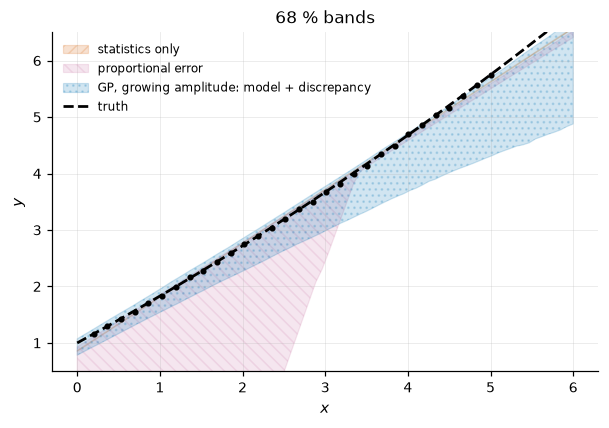

In [12]:
fig, ax = plt.subplots()
for name, colour, hatch in (
    ("statistics only", plotstyle.COLOURS[1], plotstyle.HATCHES[0]),
    ("proportional error", plotstyle.COLOURS[3], plotstyle.HATCHES[1]),
):
    lo, hi = mean_band(problems[name], samples[name])
    plotstyle.band(ax, x_fine, lo, hi, color=colour, hatch=hatch, label=name)
plotstyle.band(
    ax,
    x_fine,
    *band_gp,
    color=plotstyle.COLOURS[0],
    hatch=plotstyle.HATCHES[2],
    label="GP, growing amplitude: model + discrepancy",
)
ax.plot(x_fine, truth(x_fine), "--", color="k", label="truth")
ax.errorbar(data.x, data.y, data.y_err, fmt="o", ms=3, color="k")
ax.set(xlabel="$x$", ylabel="$y$", title="68 % bands", ylim=(0.5, 6.5))
ax.legend(fontsize=8)
plt.show()

### Which of those belongs next to the data?

The band above shows the model and its discrepancy. A real measurement also carries its own experimental error, and only the sum of the two predicts what a *measurement* would read. `predictive_draws` at the measured points includes every term by default, which is why that's the one we use for a [coverage](https://en.wikipedia.org/wiki/Coverage_probability) check, and why we don't use the band from `grid_draws` for it.

In this toy the two turn out to be very nearly the same curve, and it's worth seeing why. The experimental error is a flat 0.02, while the discrepancy's standard deviation is already 0.16 at $x = 0.2$ and 0.70 at $x = 5$. Adding 0.02 in quadrature to numbers that size changes the width by well under one per cent, and the mean 68 % predictive width at the measured points is 0.749, almost all of it discrepancy. So the choice of terms only matters when the terms are comparable in size. When they are, it matters a lot: in the $\alpha + {}^{44}$Ca study the inferred noise and the discrepancy are of the same order, and a coverage check run against the wrong object would tell us nothing.

We'll also see below that 97 % of the measured points land inside a nominal 68 % interval. That isn't a bug. It's what a mean-zero predictive *is*: it never looks at the residuals, so it can't pull itself in where the data happen to agree with the model. It tells us how far the truth *could* stray from the model, not how far it actually did.

In [13]:
lo_d, hi_d = np.percentile(draws_data, [16, 84], axis=0)
inside_d = np.mean((data.y >= lo_d) & (data.y <= hi_d))

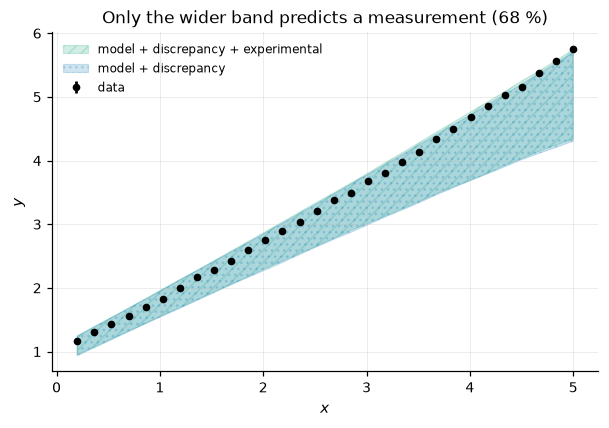

In [14]:
fig, ax = plt.subplots()
plotstyle.band(
    ax,
    data.x,
    lo_d,
    hi_d,
    color=plotstyle.COLOURS[2],
    hatch=plotstyle.HATCHES[0],
    label="model + discrepancy + experimental",
)
plotstyle.band(
    ax,
    data.x,
    np.interp(data.x, x_fine, band_gp[0]),
    np.interp(data.x, x_fine, band_gp[1]),
    color=plotstyle.COLOURS[0],
    hatch=plotstyle.HATCHES[2],
    label="model + discrepancy",
)
ax.errorbar(data.x, data.y, data.y_err, fmt="o", ms=4, color="k", label="data")
ax.set(
    xlabel="$x$",
    ylabel="$y$",
    title="Only the wider band predicts a measurement (68 %)",
)
ax.legend(fontsize=8)
plt.show()

In [15]:
print(f"fraction of the measured points inside the 68 % predictive: {inside_d:.2f}")

fraction of the measured points inside the 68 % predictive: 0.97


## The departures the data allow

Because this is synthetic data, we know the defect exactly: it's $0.03\,x^2$. So we can take the band, subtract the posterior-median line, and look at the discrepancy on its own. Remember that we drew it mean-zero, so what comes back isn't an *estimate* of the defect. It's the envelope of departures from the line that the data are willing to allow. Its centre sits at $-0.062$, which is zero to within about a tenth of its own width, and it contains the true defect over 72 % of the grid.

When our question is "where is my model wrong?", this is the honest thing to look at. A conditioned GP (`gp_predictive_draws(..., conditioned=True)`) would thread through the residuals and hug them instead. That would look far more impressive, but it would be answering a different question, one whose answer depends mostly on where the data happen to sit.

In [16]:
# the discrepancy is the band minus the line: grid_draws evaluated the growing
# amplitude on the grid, which the bare kernel object cannot
theta_gp = np.median(s_grow, axis=0)
line_median = line.bind(x_fine)(*theta_gp[p_grow.columns(line.params)])
disc_lo, disc_hi = band_gp[0] - line_median, band_gp[1] - line_median
true_defect = truth(x_fine) - line_median
resid = data.y - line.bind(x)(*theta_gp[p_grow.columns(line.params)])

In [17]:
print(
    "fraction of the grid where the true defect lies inside the 68 % envelope:",
    f"{np.mean((true_defect >= disc_lo) & (true_defect <= disc_hi)):.2f}",
)
print(f"envelope is centred on {np.mean(0.5 * (disc_lo + disc_hi)):+.3f}")

fraction of the grid where the true defect lies inside the 68 % envelope: 0.72
envelope is centred on -0.062


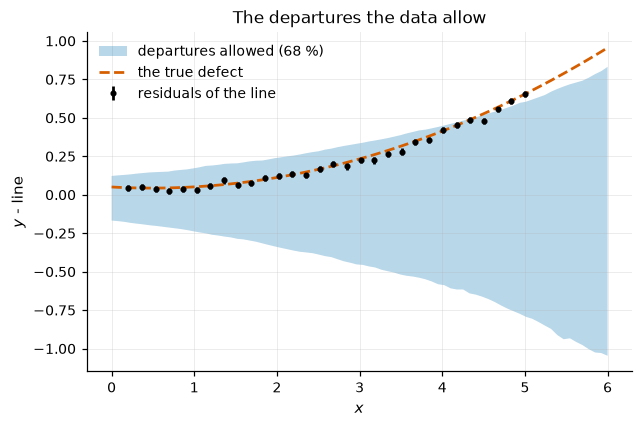

In [18]:
fig, ax = plt.subplots()
ax.errorbar(x, resid, noise, fmt="o", ms=3, color="k", label="residuals of the line")
plotstyle.band(
    ax,
    x_fine,
    disc_lo,
    disc_hi,
    color=plotstyle.COLOURS[0],
    label="departures allowed (68 %)",
)
ax.plot(x_fine, true_defect, "--", color=plotstyle.COLOURS[1], label="the true defect")
ax.set(xlabel="$x$", ylabel="$y$ - line", title="The departures the data allow")
ax.legend()
plt.show()

## The same thing on a cross section

Now let's try a real physics model with a real piece of physics missing. We generate mock $n + {}^{40}\mathrm{Ca}$ elastic scattering data at 14.1 MeV from an [optical potential](https://doi.org/10.1016/S0375-9474(02)01321-0) with both **volume and surface** absorption. Then we fit those data with a potential that only has volume absorption. The missing surface term is our structured defect.

There are two differences from the toy. First, we compare in log space, so the discrepancy is a *fractional* defect as a function of angle. Second, we drive the fit with [dynesty](https://dynesty.readthedocs.io/) ([Speagle 2020](https://doi.org/10.1093/mnras/staa278)) rather than emcee. Optical-model posteriors tend to be strongly correlated and often multimodal, and an affine-invariant ensemble sampler mixes poorly on them. [Nested sampling](https://en.wikipedia.org/wiki/Nested_sampling_algorithm) copes much better, and it hands us the evidence as a by-product.

This half of the notebook gets its own random generator, so changing anything in the toy above leaves the cross-section data untouched.

In [19]:
rng_xs = np.random.default_rng(2024)
reaction = jitr.reactions.ElasticReaction(target=(40, 20), projectile=(1, 0))
E_lab = 14.1
R40 = 40 ** (1 / 3)
mso = 1.0 / jitr.utils.constants.WAVENUMBER_PION


def full_central(r, Vv, Wv, Rv, av, Wd, Rd, ad):
    return -(Vv + 1j * Wv) * woods_saxon_safe(r, Rv, av) - 1j * Wd * (
        -4 * ad
    ) * woods_saxon_prime_safe(r, Rd, ad)


def volume_central(r, Vv, Wv, Rv, av):
    return -(Vv + 1j * Wv) * woods_saxon_safe(r, Rv, av)


def spin_orbit(r, Vso, Rso, aso):
    return Vso * mso**2 * thomas_safe(r, Rso, aso)


so_args = (6.0, 1.1 * R40, 0.45)
full_truth = np.array([48.0, 3.5, 1.1 * R40, 0.7, 21.0, 1.2 * R40, 0.5])
volume_truth = full_truth[:4]

In [20]:
full_params = [
    rx.Parameter(n, prior=stats.norm(0, 1))
    for n in ("Vv", "Wv", "Rv", "av", "Wd", "Rd", "ad")
]
omp_full = rx.reactions.ElasticXS(
    "dXS/dA",
    full_central,
    spin_orbit,
    lambda ws, *x: (tuple(x), so_args),
    full_params,
    lmax=10,
)
volume_params = [
    rx.Parameter("Vv", prior=stats.norm(48.0, 8.0), latex="V_v"),
    rx.Parameter("Wv", prior=stats.norm(4.0, 4.0), bounds=(0.0, 30.0), latex="W_v"),
    rx.Parameter("Rv", prior=stats.norm(1.15 * R40, 0.2), latex="R_v"),
    rx.Parameter("av", prior=stats.norm(0.65, 0.1), bounds=(0.3, 1.2), latex="a_v"),
]
omp_vol = rx.reactions.ElasticXS(
    "dXS/dA",
    volume_central,
    spin_orbit,
    lambda ws, *x: (tuple(x), so_args),
    volume_params,
    lmax=10,
)

In [21]:
angles = np.deg2rad(np.linspace(5.0, 160.0, 25))
meta = {"reaction": reaction, "Elab": E_lab}
y_full = omp_full.bind(angles, meta)(*full_truth)
y_xs = y_full * (1 + rng_xs.normal(0.0, 0.04, angles.size))
d_xs = rx.Dataset(angles, y_xs, 0.04 * y_xs, label="n+40Ca 14.1 MeV", meta=meta)

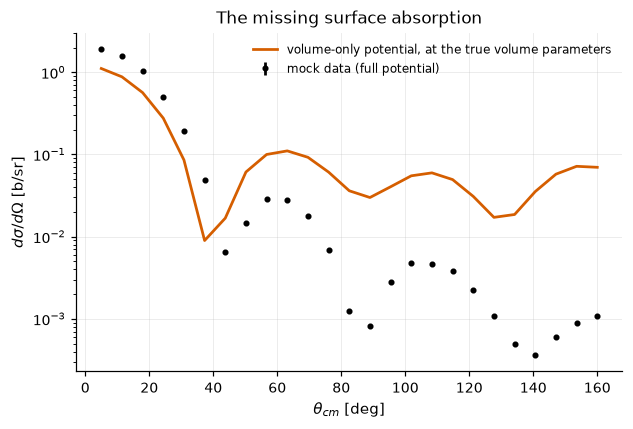

In [22]:
fig, ax = plt.subplots()
ax.errorbar(
    np.rad2deg(angles),
    d_xs.y,
    d_xs.y_err,
    fmt="o",
    ms=3,
    color="k",
    label="mock data (full potential)",
)
ax.plot(
    np.rad2deg(angles),
    omp_vol.bind(angles, meta)(*volume_truth),
    color=plotstyle.COLOURS[1],
    label="volume-only potential, at the true volume parameters",
)
ax.set(
    xlabel=r"$\theta_{cm}$ [deg]",
    ylabel=r"$d\sigma/d\Omega$ [b/sr]",
    yscale="log",
    title="The missing surface absorption",
)
ax.legend(fontsize=8)
plt.show()

### The same three rungs

We'll fit three error models: bare, an uncorrelated proportional error, and a mean-zero GP whose amplitude grows with angle. The growing amplitude carries the same prior belief as in the toy: we trust the model at forward angles and are suspicious of it at backward ones.

In [23]:
comp_xs = rx.Comparison(d_xs, omp_vol, space=tf.log)
xs_gamma = rx.Parameter(
    "log_gamma_xs", prior=stats.norm(np.log(0.05), 1.0), latex=r"\log\gamma"
)
xs_amp = rx.Parameter("log_A_xs", prior=stats.norm(np.log(0.05), 1.5), latex=r"\log A")
xs_slope = rx.Parameter("amp_slope_xs", prior=stats.norm(1.0, 1.0), latex=r"s_A")
xs_ell = rx.Parameter("log_ell_xs", prior=stats.norm(-0.5, 1.0), latex=r"\log \ell")
gp_xs = T.kernel(
    Matern(0.5, nu=2.5) + WhiteKernel(1e-6, "fixed"),
    params=[xs_ell],
    amplitude=T.exp_growth_amplitude(np.pi),
    amplitude_params=(xs_amp, xs_slope),
)
xs_problems = {
    "bare": rx.Problem([rx.Constraint([comp_xs])]),
    "proportional error": rx.Problem(
        [
            rx.Constraint(
                [comp_xs], terms=[T.proportional_error(xs_gamma, averaging=True)]
            )
        ]
    ),
    "GP, growing amplitude": rx.Problem([rx.Constraint([comp_xs], terms=[gp_xs])]),
}

In [24]:
def nested(problem, seed, nlive=150):
    sampler = dynesty.NestedSampler(
        problem.log_likelihood,
        problem.prior_transform,
        problem.ndim,
        nlive=nlive,
        sample="rwalk",
        rstate=np.random.default_rng(seed),
    )
    sampler.run_nested(dlogz=0.5, print_progress=False)
    return sampler.results


xs_results, xs_samples = {}, {}
for i, (name, p) in enumerate(xs_problems.items()):
    xs_results[name] = nested(p, 10 + i)
    xs_samples[name] = xs_results[name].samples_equal(
        rstate=np.random.default_rng(10 + i)
    )

In [25]:
for name, res in xs_results.items():
    print(
        f"{name:22s} log Z = {res.logz[-1]:8.2f} +/- {res.logzerr[-1]:.2f}, "
        f"{int(np.sum(res.ncall)):7d} likelihood calls"
    )

bare                   log Z =  -581.75 +/- 0.64,   85485 likelihood calls
proportional error     log Z =   -19.61 +/- 0.50,   64449 likelihood calls
GP, growing amplitude  log Z =    -9.93 +/- 0.52,   75404 likelihood calls


In [26]:
for name, p in xs_problems.items():
    s = xs_samples[name][:, p.columns(volume_params)]
    print(
        f"{name:22s} "
        + "  ".join(
            f"{q.name}={s[:, k].mean():6.2f}+/-{s[:, k].std():.2f}"
            for k, q in enumerate(volume_params)
        )
        + "   max|pull| = "
        + f"{max(abs((s[:, k].mean() - volume_truth[k]) / s[:, k].std()) for k in range(4)):.1f}"
    )

bare                   Vv= 26.85+/-0.41  Wv= 16.64+/-0.23  Rv=  4.43+/-0.02  av=  0.66+/-0.01   max|pull| = 56.7
proportional error     Vv= 38.78+/-3.47  Wv= 18.91+/-1.37  Rv=  4.28+/-0.15  av=  0.56+/-0.06   max|pull| = 11.3
GP, growing amplitude  Vv= 43.67+/-1.42  Wv= 13.61+/-1.07  Rv=  4.29+/-0.06  av=  0.48+/-0.02   max|pull| = 9.5


### What the three rungs did to the potential

The [evidence](https://en.wikipedia.org/wiki/Marginal_likelihood) $Z$, the probability each error model assigned to the data before fitting, is blunt about it. $\log Z$ goes from $-581.75$ for the bare fit to $-19.61$ once we allow an uncorrelated proportional error, and to $-9.93$ with the GP. The difference of two log evidences is the log of a [Bayes factor](https://en.wikipedia.org/wiki/Bayes_factor), and a gap of hundreds isn't a mild preference, it's a verdict. The bare fit claims the reported 4 % errors explain every disagreement between model and data, that claim is simply false, and the sampler can tell.

The parameters fall in the same order. The bare fit puts $V_v$ at $26.9 \pm 0.4$ MeV where the truth is 48, which is wrong by fifty standard deviations, and confidently so. The proportional error widens until nothing is precise. The GP recovers $V_v = 43.7 \pm 1.4$, about three sigma from the truth, while keeping a useful width.

Now look at $W_v$, though. It comes out at $13.6 \pm 1.1$ against a truth of 3.5, nine sigma out, in *every* rung including the GP. That isn't a failure of the discrepancy model; it's the physics. The data were generated with volume **and** surface absorption, we fitted a potential with only volume absorption, and at a single energy those two shapes are very hard to tell apart. The fitted volume absorption is quite literally soaking up the missing surface term.

This is an honest limit of the method, and it's worth stating plainly. A discrepancy model widens what we don't know, and stops the fit from overstating its precision. It can't recover information the measurement never contained.

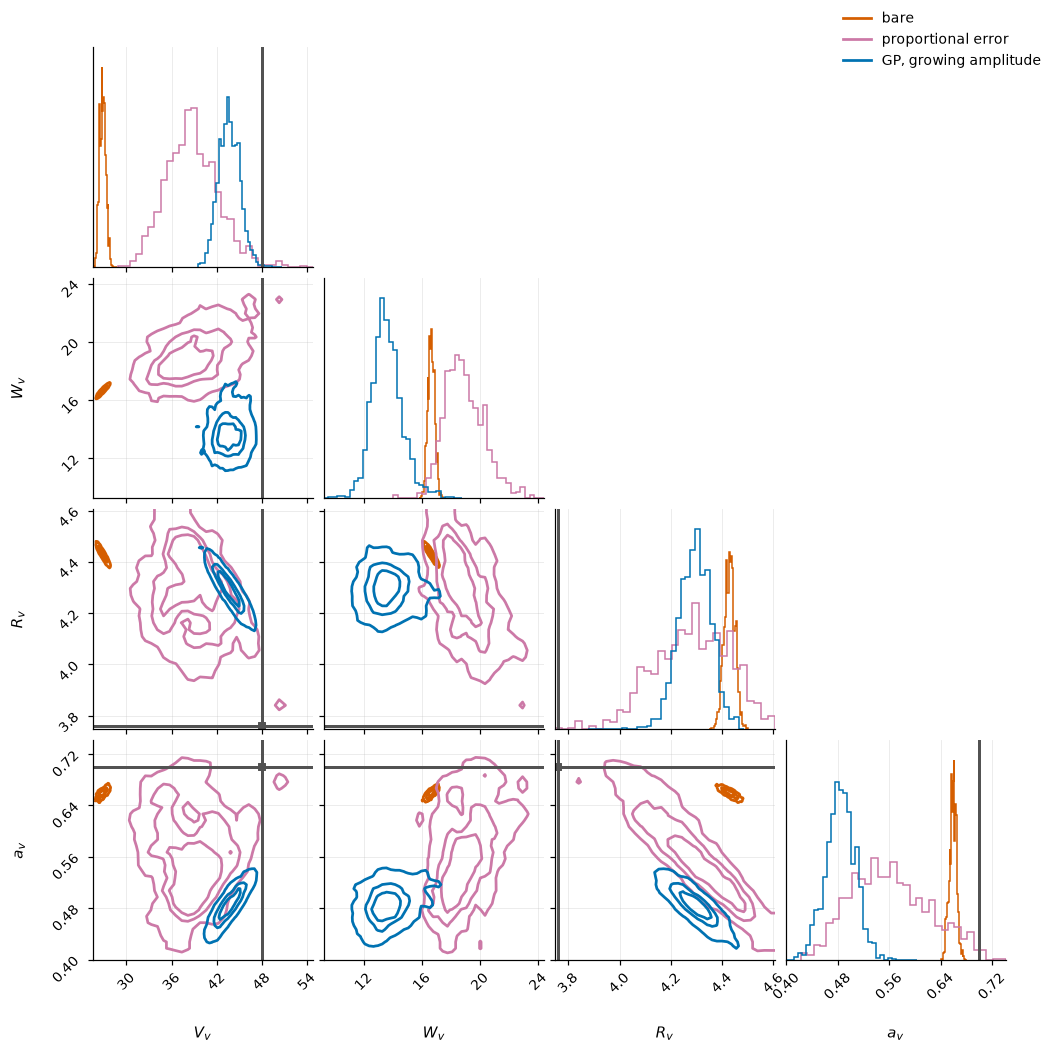

In [27]:
labels = [f"${q.latex}$" for q in volume_params]
fig = None
xs_colours = [plotstyle.COLOURS[i] for i in (1, 3, 0)]
for (name, p), colour in zip(xs_problems.items(), xs_colours):
    fig = corner.corner(
        xs_samples[name][:, p.columns(volume_params)],
        fig=fig,
        labels=labels,
        truths=volume_truth,
        **plotstyle.corner_kwargs(
            color=colour, fill_contours=False, plot_density=False, show_titles=False
        ),
    )
fig.legend(
    handles=[
        plt.Line2D([], [], color=c, label=n) for n, c in zip(xs_problems, xs_colours)
    ],
    loc="upper right",
    fontsize=9,
)
plt.show()

### The learned discrepancy against the missing physics

The defect our GP has to describe is the log of the ratio between the full potential that generated the data and the volume-only one we fitted. We'll draw it at the posterior-median volume parameters, on a finer angular grid than the data, so we can see how the GP interpolates between measured angles and how it behaves beyond them.

In [28]:
p_xs_gp = xs_problems["GP, growing amplitude"]
s_xs_gp = xs_samples["GP, growing amplitude"]
theta_xs = np.median(s_xs_gp, axis=0)
fine = np.deg2rad(np.linspace(2.0, 178.0, 90))
resid_xs = comp_xs.y - comp_xs.predict(*theta_xs[p_xs_gp.columns(volume_params)])

# again the band minus the fitted model, both in log space; naming the
# kernel gives the model plus its discrepancy, with no experimental error
rows_xs = s_xs_gp[np.random.default_rng(5).choice(len(s_xs_gp), 100, replace=False)]
band_xs = rx.predictive.grid_draws(
    p_xs_gp,
    omp_vol.bind(fine, meta),
    fine,
    rows_xs,
    terms=[gp_xs],
    levels=(16, 84),
    rng=5,
)
mu_fine = comp_xs.space(
    omp_vol.bind(fine, meta)(*theta_xs[p_xs_gp.columns(volume_params)])
)
disc_lo_xs, disc_hi_xs = band_xs[0] - mu_fine, band_xs[1] - mu_fine
true_defect_xs = np.log(omp_full.bind(fine, meta)(*full_truth)) - mu_fine

In [29]:
print(
    "fraction of the grid where the true defect is inside the 68 % envelope:",
    f"{np.mean((true_defect_xs >= disc_lo_xs) & (true_defect_xs <= disc_hi_xs)):.2f}",
)

fraction of the grid where the true defect is inside the 68 % envelope: 0.59


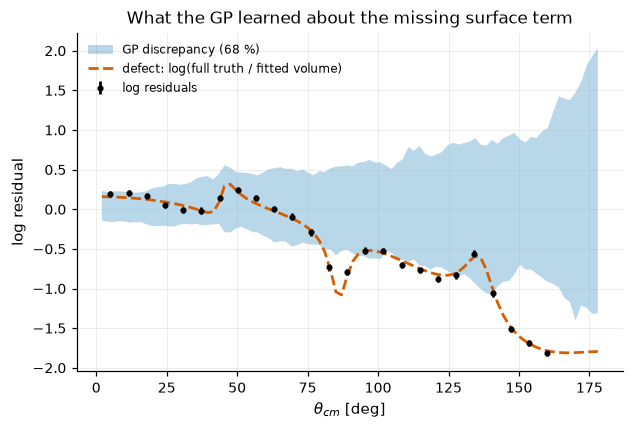

In [30]:
fig, ax = plt.subplots()
ax.errorbar(
    np.rad2deg(angles),
    resid_xs,
    comp_xs.y_err,
    fmt="o",
    ms=3,
    color="k",
    label="log residuals",
)
plotstyle.band(
    ax,
    np.rad2deg(fine),
    disc_lo_xs,
    disc_hi_xs,
    color=plotstyle.COLOURS[0],
    label="GP discrepancy (68 %)",
)
ax.plot(
    np.rad2deg(fine),
    true_defect_xs,
    "--",
    color=plotstyle.COLOURS[1],
    label="defect: log(full truth / fitted volume)",
)
ax.set(
    xlabel=r"$\theta_{cm}$ [deg]",
    ylabel="log residual",
    title="What the GP learned about the missing surface term",
)
ax.legend(fontsize=8)
plt.show()

## Takeaways

- A mean-zero GP discrepancy is just another covariance term. `grid_draws` can propagate it onto any grid from the problem alone, and it does so as whole correlated curves rather than columns of independent points, so questions about the curve as a whole make sense.
- We met two predictive objects, and they answer different questions. The model plus its discrepancy tells us where the model may be wrong. Adding the experimental terms tells us what a *measurement* should look like, and only that second one belongs next to data. `terms=` is how we pick. There's also a third, conditioning the discrepancy on the residuals with `gp_predictive_draws(..., conditioned=True)`, but that's data-driven regression stacked on the model, and we deliberately didn't use it here.
- The envelope isn't a fit to the defect, and nothing guarantees it covers the defect. It contained the toy's defect over 72 % of the grid, but the cross section's over only 59 %, where the fitted potential had already absorbed part of the missing physics into $W_v$. A mean-zero predictive describes plausible error, and it can be too narrow as well as too generous.
- An unmodelled discrepancy doesn't make our answer vague; it makes it *wrong and confident*. On the toy that meant a slope sixty sigma from the truth.
- An uncorrelated proportional error can only inflate. It covers the truth by making the parameters meaningless, because independent slack at each point can't describe a coherent, smooth departure.
- The amplitude is prior knowledge, and it's worth stating. A constant amplitude has to be generous everywhere to cover the worst region. Letting it grow with $x$ keeps the fit honest where the model is good and forgiving where it isn't.
- None of this creates information. Where the data can't separate two effects, like volume and surface absorption at a single energy, the discrepancy model widens the answer rather than pretending to resolve it.